In [ ]:
 # !pip install darts --quiet

In [ ]:
# !pip install numpy==1.26.4 pmdarima==2.0.4 --force-reinstall
# import os
# os.kill(os.getpid(), 9)

In [1]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 18.3 MB/s eta 0:00:00


In [2]:

import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
import torch.nn as nn
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from tensorflow.keras.utils import plot_model

# Read Data & Feature Technical


In [3]:
df = pd.read_csv('/content/MERGE_SAHAM_GABUNGAN_FINAL (1).csv', parse_dates=['tanggal'])
df = df.sort_values('tanggal')
df = df.drop(columns=['Unnamed: 0'])

In [4]:
# Fitur teknikal dasar
df['return'] = df['Terakhir'].pct_change() # <- buat melihat return harian (persentase perubahan)
df['lag1_return'] = df['return'].shift(1) # <- untuk melihat pengaruh return sebelumnya terhadap return saat ini
df['ma5'] = df['Terakhir'].rolling(5).mean().shift(1) # <- membuat moving average 5 hari dari harga 'Terakhir', lalu digeser 1 hari ke belakang
df['ma10'] = df['Terakhir'].rolling(10).mean().shift(1) # <- membuat moving average 10 hari dari harga 'Terakhir', lalu digeser 1 hari ke belakang
df['volatility5'] = df['return'].rolling(5).std().shift(1) # <- menghitung volatility 5 hari terakhir dan digeser 1 hari ke belakang
df['dayofweek'] = df['tanggal'].dt.dayofweek # <- mengambil hari dalam minggu

In [5]:
df.head()

,tanggal,Terakhir,Pembukaan,Tertinggi,Terendah,Vol.,Perubahan%,avg_sentiment,prop_pos,prop_neg,prop_neu,count,max_impact,return,lag1_return,ma5,ma10,volatility5,dayofweek
0,2022-01-03,6665.31,6586.26,6677.20,6586.13,1.826000e+10,1.27,0.000000,0.0,0.0,1.0,1.0,netral,NaN,NaN,NaN,NaN,NaN,0
1,2022-01-04,6695.37,6675.13,6720.66,6675.13,1.859000e+10,0.45,0.789194,1.0,0.0,0.0,2.0,positif,0.004510,NaN,NaN,NaN,NaN,1
2,2022-01-05,6662.30,6703.17,6738.11,6634.84,1.791000e+10,-0.49,0.000000,0.0,0.0,1.0,0.0,netral,-0.004939,0.004510,NaN,NaN,NaN,2
3,2022-01-06,6653.35,6674.85,6679.85,6593.23,1.800000e+10,-0.13,-0.646163,0.0,1.0,0.0,1.0,negatif,-0.001343,-0.004939,NaN,NaN,NaN,3
4,2022-01-07,6701.32,6669.51,6712.15,6647.71,1.571000e+10,0.72,0.500000,0.5,0.0,0.5,2.0,positif,0.007210,-0.001343,NaN,NaN,NaN,4


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 722 entries, 0 to 721
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   tanggal        722 non-null    datetime64[ns]
 1   Terakhir       722 non-null    float64       
 2   Pembukaan      722 non-null    float64       
 3   Tertinggi      722 non-null    float64       
 4   Terendah       722 non-null    float64       
 5   Vol.           722 non-null    float64       
 6   Perubahan%     722 non-null    float64       
 7   avg_sentiment  722 non-null    float64       
 8   prop_pos       722 non-null    float64       
 9   prop_neg       722 non-null    float64       
 10  prop_neu       722 non-null    float64       
 11  count          722 non-null    float64       
 12  max_impact     722 non-null    object        
 13  return         721 non-null    float64       
 14  lag1_return    720 non-null    float64       
 15  ma5            717 non-

In [7]:
df.dropna(axis=0, inplace=True) #menghapus nilai N/A

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 10 to 721
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   tanggal        712 non-null    datetime64[ns]
 1   Terakhir       712 non-null    float64       
 2   Pembukaan      712 non-null    float64       
 3   Tertinggi      712 non-null    float64       
 4   Terendah       712 non-null    float64       
 5   Vol.           712 non-null    float64       
 6   Perubahan%     712 non-null    float64       
 7   avg_sentiment  712 non-null    float64       
 8   prop_pos       712 non-null    float64       
 9   prop_neg       712 non-null    float64       
 10  prop_neu       712 non-null    float64       
 11  count          712 non-null    float64       
 12  max_impact     712 non-null    object        
 13  return         712 non-null    float64       
 14  lag1_return    712 non-null    float64       
 15  ma5            712 non-null

In [9]:
impact_mapping = {'negatif': -1, 'netral': 0, 'positif': 1}
df['max_impact_num'] = df['max_impact'].map(impact_mapping)

## **Uji ADF**

In [10]:
from statsmodels.tsa.stattools import adfuller

def perform_adf_test(series, name):
    print(f'Hasil Uji ADF untuk: {name}')
    # autolag='AIC' akan memilih lag terbaik secara otomatis
    result = adfuller(series, autolag='AIC')

    labels = ['ADF Statistic', 'p-value', '#Lags Used', 'Number of Observations Used']
    for value, label in zip(result, labels):
        print(f'{label} : {value}')

    if result[1] <= 0.05:
        print("Kesimpulan: Data STASIONER (Siap digunakan)")
    else:
        print("Kesimpulan: Data TIDAK STASIONER (Perlu Differencing)")

perform_adf_test(df['Terakhir'], 'Terakhir')

Hasil Uji ADF untuk: Terakhir
ADF Statistic : -2.9901114249516723
p-value : 0.035828245107997723
#Lags Used : 4
Number of Observations Used : 707
Kesimpulan: Data STASIONER (Siap digunakan)


In [11]:
perform_adf_test(df['Perubahan%'], 'Perubahan%')

Hasil Uji ADF untuk: Perubahan%
ADF Statistic : -28.245064557606888
p-value : 0.0
#Lags Used : 0
Number of Observations Used : 711
Kesimpulan: Data STASIONER (Siap digunakan)


In [12]:
perform_adf_test(df['avg_sentiment'], 'avg_sentiment')

Hasil Uji ADF untuk: avg_sentiment
ADF Statistic : -24.663942553897343
p-value : 0.0
#Lags Used : 0
Number of Observations Used : 711
Kesimpulan: Data STASIONER (Siap digunakan)


In [13]:
perform_adf_test(df['return'], 'return')

Hasil Uji ADF untuk: return
ADF Statistic : -28.242394387874267
p-value : 0.0
#Lags Used : 0
Number of Observations Used : 711
Kesimpulan: Data STASIONER (Siap digunakan)


In [14]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

X = df[['Pembukaan', 'Tertinggi', 'Terendah', 'Vol.', 'Perubahan%',
        'avg_sentiment', 'prop_pos', 'prop_neg', 'prop_neu', 'max_impact_num',
        'return', 'lag1_return', 'ma5', 'ma10', 'volatility5', 'dayofweek']]
y = df['Terakhir'].shift(-1)

mask = ~(X.isna().any(axis=1) | y.isna())
X_clean = X[mask]
y_clean = y[mask]

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_clean, y_clean)

importance = pd.Series(model.feature_importances_, index=X_clean.columns).sort_values(ascending=False)
print(importance)

Terendah          0.528159
Tertinggi         0.328806
Pembukaan         0.111891
return            0.004267
lag1_return       0.003897
volatility5       0.003874
ma5               0.003649
Perubahan%        0.003583
ma10              0.003574
Vol.              0.003384
dayofweek         0.001483
avg_sentiment     0.000945
prop_neu          0.000864
prop_neg          0.000718
prop_pos          0.000611
max_impact_num    0.000297
dtype: float64


## OLS Result

In [15]:
import statsmodels.api as sm

# x adalah skor sentimen dan y adalah return IHSG
X = df['avg_sentiment']
y = df['Terakhir']

# Menambahkan konstanta (beta 0)
X = sm.add_constant(X)

# Membuat model OLS (Ordinary Least Squares)
model = sm.OLS(y, X).fit()

# Menampilkan hasil full report
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               Terakhir   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     3.813
Date:                Tue, 03 Mar 2026   Prob (F-statistic):             0.0512
Time:                        06:25:44   Log-Likelihood:                -4990.2
No. Observations:                 712   AIC:                             9984.
Df Residuals:                     710   BIC:                             9993.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          7039.7192     10.592    664.620

# Spliting data menggunakan chronological

In [16]:
from sklearn.preprocessing import StandardScaler

feature_cols = ['Pembukaan',
                'Tertinggi',
                'Terendah',
                'Vol.',
                'avg_sentiment',
                'return',
                'lag1_return',
                'ma5',
                'ma10',
                'volatility5']

df['target'] = df['Terakhir'].shift(-1)

train = df[(df['tanggal'] >= "2022-01-03") & (df['tanggal'] <= "2022-12-31")].copy()
val   = df[(df['tanggal'] >= "2023-01-03") & (df['tanggal'] <= "2023-06-30")].copy()
test  = df[(df['tanggal'] >= "2023-07-01") & (df['tanggal'] <= "2024-12-31")].copy()

# Drop NA akibat rolling & shift
train = train[feature_cols + ['target']].dropna()
val   = val[feature_cols + ['target']].dropna()
test  = test[feature_cols + ['target']].dropna()

scaler_X = StandardScaler()
scaler_y = StandardScaler()

scaler_X.fit(train[feature_cols])
scaler_y.fit(train[['target']])

def scale(df):
    X = pd.DataFrame(
        scaler_X.transform(df[feature_cols]),
        columns=feature_cols,
        index=df.index
    )
    y = pd.DataFrame(
        scaler_y.transform(df[['target']]),
        columns=['target_scaled'],
        index=df.index
    )
    return pd.concat([X, y], axis=1)

train_scaled = scale(train)
val_scaled   = scale(val)
test_scaled  = scale(test)


In [17]:
import numpy as np

def create_sequences(df_scaled, seq_len):
    X, y = [], []
    for i in range(seq_len, len(df_scaled)):
        X.append(
            df_scaled.iloc[i-seq_len:i]
            .drop(columns=['target_scaled'])
            .values
        )
        y.append(df_scaled['target_scaled'].iloc[i])
    return np.array(X), np.array(y)

SEQ_LEN = 1

X_train, y_train = create_sequences(train_scaled, SEQ_LEN)
X_val,   y_val   = create_sequences(val_scaled,   SEQ_LEN)
X_test,  y_test  = create_sequences(test_scaled,  SEQ_LEN)


In [18]:
X_train.shape

(235, 1, 10)

In [19]:
lengths = [len(seq) for seq in X_train]
set(lengths)

{1}

# LSTM

In [20]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras import models, layers, callbacks, optimizers
import itertools
import warnings
warnings.filterwarnings('ignore')

# Set seed
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)
import random
random.seed(42)

# Parameter grid
param_grid = {
    'lstm_units_1': [64, 128],        # dari 3 → 2
    'lstm_units_2': [32],             # dari 3 → 1
    'dense_units': [32, 64],          # dari 3 → 2
    'dropout_rate': [0.2],            # dari 3 → 1
    'learning_rate': [0.001, 0.0001], # tetap 2
    'batch_size': [32, 64],           # dari 3 → 2
}

# Generate semua kombinasi
param_names = list(param_grid.keys())
param_values = list(param_grid.values())
all_combinations = list(itertools.product(*param_values))

total = len(all_combinations)
print(f"\n{'='*80}")
print(f"Total kombinasi: {total}")
print(f"{'='*80}\n")

results_list = []
n_features = X_train.shape[2]

# Loop semua kombinasi
for idx, combination in enumerate(all_combinations, 1):
    params = dict(zip(param_names, combination))

    # Progress bar
    progress = (idx / total) * 100
    filled = int(40 * idx // total)
    bar = '█' * filled + '░' * (40 - filled)
    print(f"\r[{bar}] {progress:.1f}% | Eksperimen {idx}/{total}", end='', flush=True)

    try:
        # Buat model
        model = models.Sequential([
            layers.Input(shape=(SEQ_LEN, n_features)),
            layers.Masking(),
            layers.LSTM(params['lstm_units_1'], return_sequences=True),
            layers.Dropout(params['dropout_rate']),
            layers.LSTM(params['lstm_units_2']),
            layers.Dense(params['dense_units'], activation='relu'),
            layers.Dense(1)
        ])

        model.compile(
            optimizer=optimizers.Adam(learning_rate=params['learning_rate']),
            loss='mse',
            metrics=['mae']
        )

        # Early stopping
        es = callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=0
        )

        # Training
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=100,
            batch_size=params['batch_size'],
            callbacks=[es],
            verbose=0
        )

        # Prediksi
        y_pred_test = model.predict(X_test, verbose=0).flatten()
        y_test_original = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
        y_pred_test_original = scaler_y.inverse_transform(y_pred_test.reshape(-1, 1)).flatten()

        # Hitung metrik
        mae_lstm = mean_absolute_error(y_test_original, y_pred_test_original)
        mse_lstm = mean_squared_error(y_test_original, y_pred_test_original)
        rmse_lstm = np.sqrt(mse_lstm)

        non_zero_mask = y_test_original != 0
        if non_zero_mask.sum() > 0:
            mape_lstm = np.mean(np.abs((y_test_original[non_zero_mask] - y_pred_test_original[non_zero_mask]) /
                                  y_test_original[non_zero_mask])) * 100
        else:
            mape_lstm = np.nan

        # Simpan hasil
        results_list.append({
            **params,
            'test_mae': mae_lstm,
            'test_mse': mse_lstm,
            'test_rmse': rmse_lstm,
            'test_mape': mape_lstm,
            'epochs_trained': len(history.history['loss'])
        })

    except Exception as e:
        print(f"\nError pada kombinasi {idx}: {str(e)}")
        continue

print(f"\n\n{'='*80}")

# Buat DataFrame hasil
results_df = pd.DataFrame(results_list)

# STATISTIK UMUM
print("\n" + "="*80)
print("STATISTIK UMUM EKSPERIMEN")
print("="*80 + "\n")
print(f"Total model diuji      : {len(results_df)}")
# Corrected lines: removed lambda function for min/max/mean
print(f"RMSE terbaik          : {results_df['test_rmse'].min()}")
print(f"RMSE terburuk         : {results_df['test_rmse'].max()}")
print(f"RMSE rata-rata        : {results_df['test_rmse'].mean()}")
print(f"MAE terbaik           : {results_df['test_mae'].min()}")
print(f"MAPE terbaik          : {results_df['test_mape'].min():.2f}%")

# TOP 10 TERBAIK
print("\n" + "="*80)
print("TOP 10 MODEL TERBAIK (Berdasarkan Test MAPE)")
print("="*80 + "\n")

top_5 = results_df.nsmallest(5, 'test_mape').reset_index(drop=True)

display_df = pd.DataFrame({
    'Rank': range(1, len(top_5) + 1),
    'LSTM1': top_5['lstm_units_1'].astype(int),
    'LSTM2': top_5['lstm_units_2'].astype(int),
    'Dense': top_5['dense_units'].astype(int),
    'Dropout': top_5['dropout_rate'].round(2),
    'LR': top_5['learning_rate'],
    'Batch': top_5['batch_size'].astype(int),
    'MSE': top_5['test_mse'].apply(lambda x: f"{x:.2f}"),
    'RMSE': top_5['test_rmse'].apply(lambda x: f"{x:.2f}"),
    'MAE': top_5['test_mae'].apply(lambda x: f"{x:.2f}"),
    'MAPE%': top_5['test_mape'].round(2),
    'Epochs': top_5['epochs_trained'].astype(int)
})

print(display_df.to_string(index=False))

# DETAIL MODEL TERBAIK
print("\n" + "="*80)
print("DETAIL MODEL TERBAIK (#1)")
print("="*80 + "\n")

best = top_5.iloc[0]

print("PARAMETER:")
print(f"  • LSTM Layer 1        : {int(best['lstm_units_1'])} units")
print(f"  • LSTM Layer 2        : {int(best['lstm_units_2'])} units")
print(f"  • Dense Layer         : {int(best['dense_units'])} units")
print(f"  • Dropout Rate        : {best['dropout_rate']}")
print(f"  • Learning Rate       : {best['learning_rate']}")
print(f"  • Batch Size          : {int(best['batch_size'])}")
print(f"  • Epochs Trained      : {int(best['epochs_trained'])}")

print("\nMETRIK EVALUASI:")
# Corrected lines: removed lambda function for scalar values
print(f"  • Test MSE           : {best['test_mse']}")
print(f"  • Test RMSE           : {best['test_rmse']}")
print(f"  • Test MAE            : {best['test_mae']}")
print(f"  • Test MAPE           : {best['test_mape']:.2f}%")

print("\n" + "="*80 + "\n")


Total kombinasi: 16

[████████████████████████████████████████] 100.0% | Eksperimen 16/16


STATISTIK UMUM EKSPERIMEN

Total model diuji      : 16
RMSE terbaik          : 161.28330821346
RMSE terburuk         : 262.1704220051631
RMSE rata-rata        : 180.69215420990292
MAE terbaik           : 117.6675084635417
MAPE terbaik          : 1.59%

TOP 10 MODEL TERBAIK (Berdasarkan Test MAPE)

 Rank  LSTM1  LSTM2  Dense  Dropout     LR  Batch      MSE   RMSE    MAE  MAPE%  Epochs
    1    128     32     64      0.2 0.0001     64 26699.16 163.40 117.67   1.59     100
    2    128     32     32      0.2 0.0001     32 26012.31 161.28 119.25   1.62     100
    3    128     32     64      0.2 0.0001     32 27242.96 165.05 121.39   1.64     100
    4    128     32     32      0.2 0.0001     64 29192.33 170.86 124.21   1.68     100
    5    128     32     64      0.2 0.0010     64 29093.57 170.57 125.28   1.70      49

DETAIL MODEL TERBAIK (#1)

PARAMETER:
  • LSTM Layer 1        : 128 units
  • L

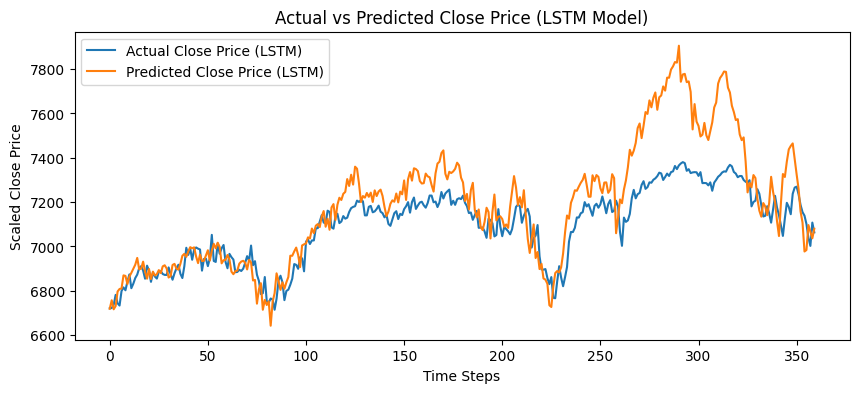

In [21]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(y_pred_test_original.flatten(), label="Actual Close Price (LSTM)")
plt.plot(y_test_original.flatten(), label="Predicted Close Price (LSTM)")
plt.title("Actual vs Predicted Close Price (LSTM Model)")
plt.xlabel("Time Steps")
plt.ylabel("Scaled Close Price")
plt.legend()
plt.show()

# N-Beats

In [22]:
import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
from itertools import product
# Notebook — ada seed
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

def nbeats_block(x, units, input_dim, name_prefix=''):
    h = layers.Dense(units, activation='relu', name=f'{name_prefix}_fc1')(x)
    h = layers.Dense(units, activation='relu', name=f'{name_prefix}_fc2')(h)
    h = layers.Dense(units, activation='relu', name=f'{name_prefix}_fc3')(h)
    h = layers.Dense(units, activation='relu', name=f'{name_prefix}_fc4')(h)
    backcast = layers.Dense(input_dim, name=f'{name_prefix}_backcast')(h)
    forecast = layers.Dense(1, name=f'{name_prefix}_forecast')(h)
    return backcast, forecast


input_dim = SEQ_LEN * len(feature_cols)
def create_nbeats_model(input_dim, units_config, learning_rate):
    inputs = layers.Input(shape=(input_dim,), name='input')

    # Block 1
    backcast1, forecast1 = nbeats_block(inputs, units=units_config[0],
                                        input_dim=input_dim, name_prefix='generic1')
    res1 = layers.Subtract(name='residual1')([inputs, backcast1])

    # Block 2
    backcast2, forecast2 = nbeats_block(res1, units=units_config[1],
                                        input_dim=input_dim, name_prefix='generic2')
    res2 = layers.Subtract(name='residual2')([res1, backcast2])

    # Block 3
    backcast3, forecast3 = nbeats_block(res2, units=units_config[2],
                                        input_dim=input_dim, name_prefix='trend1')
    res3 = layers.Subtract(name='residual3')([res2, backcast3])

    # Block 4
    backcast4, forecast4 = nbeats_block(res3, units=units_config[3],
                                        input_dim=input_dim, name_prefix='trend2')

    # Final output
    output = layers.Add(name='final_forecast')([forecast1, forecast2, forecast3, forecast4])

    model = Model(inputs=inputs, outputs=output, name='NBEATS')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )

    return model


def train_and_evaluate(X_train_flat, y_train, X_val_flat, y_val,
                       X_test_flat, y_test, scaler_y, input_dim, config):
    print(f"\n{'='*70}")
    print(f"Testing configuration: {config}")
    print(f"{'='*70}")

    # Clear session untuk menghindari memory leak
    tf.keras.backend.clear_session()

    # Create model
    model = create_nbeats_model(
        input_dim=input_dim,
        units_config=config['units'],
        learning_rate=config['learning_rate']
    )

    # Callbacks
    es = callbacks.EarlyStopping(
        monitor='val_loss',
        patience=config['patience'],
        restore_best_weights=True,
        verbose=0
    )

    reduce_lr = callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=15,
        min_lr=1e-6,
        verbose=0
    )

    # Train
    history = model.fit(
        X_train_flat, y_train,
        validation_data=(X_val_flat, y_val),
        epochs=config['epochs'],
        batch_size=config['batch_size'],
        callbacks=[es, reduce_lr],
        verbose=0
    )

    # Predict
    y_pred_scaled = model.predict(X_test_flat, verbose=0)
    y_pred = scaler_y.inverse_transform(y_pred_scaled)
    y_true = scaler_y.inverse_transform(y_test.reshape(-1, 1))

    # Calculate metrics
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    # Validation metrics
    val_loss = min(history.history['val_loss'])
    val_mae = min(history.history['val_mae'])

    results = {
        'config': str(config),
        'units': str(config['units']),
        'learning_rate': config['learning_rate'],
        'batch_size': config['batch_size'],
        'epochs': config['epochs'],
        'patience': config['patience'],
        'mae': mae,
        'rmse': rmse,
        'mse': mse,
        'mape': mape,
        'val_loss': val_loss,
        'val_mae': val_mae,
        'final_epoch': len(history.history['loss'])
    }

    print(f"Results:")
    print(f"  Test MSE   : {mse:.2f}")
    print(f"  Test MAE  : {mae:.2f}")
    print(f"  Test RMSE : {rmse:.2f}")
    print(f"  Test MAPE : {mape:.2f}%")
    print(f"  Val Loss  : {val_loss:.4f}")
    print(f"  Epochs    : {len(history.history['loss'])}")

    return results, model, history

def manual_search_experiment(X_train_flat, y_train, X_val_flat, y_val,
                             X_test_flat, y_test, scaler_y, input_dim):

    print("\n" + "="*70)
    print("MANUAL HYPERPARAMETER TESTING")
    print("="*70)

    # Konfigurasi yang akan diuji
    configs = [
        {
            'units': [128, 128, 64, 64],
            'learning_rate': 0.001,
            'batch_size': 32,
            'epochs': 100,
            'patience': 15
        },
        {
            'units': [64, 64, 32, 32],
            'learning_rate': 0.01,
            'batch_size': 64,
            'epochs': 100,
            'patience': 10
        },
        {
            'units': [256, 256, 128, 128],
            'learning_rate': 0.0001,
            'batch_size': 16,
            'epochs': 100,
            'patience': 20
        },
        {
            'units': [256, 128, 64, 32],
            'learning_rate': 0.001,
            'batch_size': 32,
            'epochs': 100,
            'patience': 15
        },
        {
            'units': [128, 128, 64, 64],
            'learning_rate': 0.0005,
            'batch_size': 32,
            'epochs': 150,
            'patience': 20
        },
    ]

    results_list = []

    for config in configs:
      print(f"\nTesting config: {config}")

      try:
          result, _, _ = train_and_evaluate(
              X_train_flat, y_train, X_val_flat, y_val,
              X_test_flat, y_test, scaler_y, input_dim, config
          )
          results_list.append(result)
      except Exception as e:
          print(f"Error: {str(e)}")
          continue

    results_df = pd.DataFrame(results_list)
    results_df = results_df.sort_values('mape')

    return results_df

#hasil
def display_results(results_df, top_n=5):
    print("\n" + "="*100)
    print(f"TOP {top_n} BEST CONFIGURATIONS")
    print("="*100)

    display_cols = ['units', 'learning_rate', 'batch_size', 'patience',
                    'mae','mse', 'rmse', 'mape', 'final_epoch']

    display_df = results_df[display_cols].head(top_n).copy()
    display_df['mape'] = display_df['mape'].apply(lambda x: f"{x:.2f}%")

    print(display_df.to_string(index=False))

    print("\n" + "="*100)
    print("BEST CONFIGURATION:")
    print("="*100)
    best = results_df.iloc[0]
    print(f"Units         : {best['units']}")
    print(f"Learning Rate : {best['learning_rate']}")
    print(f"Batch Size    : {best['batch_size']}")
    print(f"Patience      : {best['patience']}")
    print(f"\nTest Performance:")
    print(f"  MAE  : {best['mae']:.2f}")
    print(f"  RMSE : {best['rmse']:.2f}")
    print(f"  MAPE : {best['mape']:.2f}%")
    print(f"  MSE  : {best['mse']:.2f}")
    print(f"\nValidation Loss: {best['val_loss']:.4f}")
    print(f"Epochs Trained : {best['final_epoch']}")

    return best

#retrain
def retrain_best_model(X_train_flat, y_train, X_val_flat, y_val,
                       X_test_flat, y_test, scaler_y, input_dim, best_config):
    print("\n" + "="*70)
    print("RETRAINING BEST MODEL WITH VERBOSE OUTPUT")
    print("="*70)

    # Extract config
    import ast
    units = ast.literal_eval(best_config['units']) if isinstance(best_config['units'], str) else best_config['units']

    config = {
        'units': units,
        'learning_rate': best_config['learning_rate'],
        'batch_size': int(best_config['batch_size']),
        'epochs': int(best_config['epochs']),
        'patience': int(best_config['patience'])
    }

    # Clear session
    tf.keras.backend.clear_session()

    # Create model
    model = create_nbeats_model(
        input_dim=input_dim,
        units_config=config['units'],
        learning_rate=config['learning_rate']
    )

    print(model.summary())

    # Callbacks
    es = callbacks.EarlyStopping(
        monitor='val_loss',
        patience=config['patience'],
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=20,
        min_lr=1e-6,
        verbose=1
    )

    # Train with verbose
    history = model.fit(
        X_train_flat, y_train,
        validation_data=(X_val_flat, y_val),
        epochs=config['epochs'],
        batch_size=config['batch_size'],
        callbacks=[es, reduce_lr],
        verbose=1
    )

    # Final evaluation
    y_pred_scaled = model.predict(X_test_flat)
    y_pred = scaler_y.inverse_transform(y_pred_scaled)
    y_true = scaler_y.inverse_transform(y_test.reshape(-1, 1))

    mae_nbeats = mean_absolute_error(y_true, y_pred)
    mse_nbeats = mean_squared_error(y_true, y_pred)
    rmse_nbeats = np.sqrt(mse_nbeats)
    mape_nbeats = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print("\n" + "="*60)
    print("FINAL N-BEATS MODEL PERFORMANCE (Test Set)")
    print("="*60)
    print(f"MAE  : {mae_nbeats:.2f}")
    print(f"RMSE : {rmse_nbeats:.2f}")
    print(f"MAPE : {mape_nbeats:.2f}%")
    print(f"MSE  : {mse_nbeats:.2f}")

    return model, history

# Flatten data
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

results_manual = manual_search_experiment(
    X_train_flat, y_train, X_val_flat, y_val,
    X_test_flat, y_test, scaler_y, input_dim
)
best_config_manual = display_results(results_manual, top_n=5)


MANUAL HYPERPARAMETER TESTING

Testing config: {'units': [128, 128, 64, 64], 'learning_rate': 0.001, 'batch_size': 32, 'epochs': 100, 'patience': 15}

Testing configuration: {'units': [128, 128, 64, 64], 'learning_rate': 0.001, 'batch_size': 32, 'epochs': 100, 'patience': 15}
Results:
  Test MSE   : 19340.23
  Test MAE  : 108.94
  Test RMSE : 139.07
  Test MAPE : 1.49%
  Val Loss  : 0.1350
  Epochs    : 19

Testing config: {'units': [64, 64, 32, 32], 'learning_rate': 0.01, 'batch_size': 64, 'epochs': 100, 'patience': 10}

Testing configuration: {'units': [64, 64, 32, 32], 'learning_rate': 0.01, 'batch_size': 64, 'epochs': 100, 'patience': 10}
Results:
  Test MSE   : 26731.43
  Test MAE  : 126.88
  Test RMSE : 163.50
  Test MAPE : 1.72%
  Val Loss  : 0.1121
  Epochs    : 13

Testing config: {'units': [256, 256, 128, 128], 'learning_rate': 0.0001, 'batch_size': 16, 'epochs': 100, 'patience': 20}

Testing configuration: {'units': [256, 256, 128, 128], 'learning_rate': 0.0001, 'batch_size

In [23]:
import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks

import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.backend.clear_session()
def nbeats_block(x, units, input_dim, name_prefix=''):
    h = layers.Dense(units, activation='relu', name=f'{name_prefix}_fc1')(x)
    h = layers.Dense(units, activation='relu', name=f'{name_prefix}_fc2')(h)
    h = layers.Dense(units, activation='relu', name=f'{name_prefix}_fc3')(h)
    h = layers.Dense(units, activation='relu', name=f'{name_prefix}_fc4')(h)
    backcast = layers.Dense(input_dim, name=f'{name_prefix}_backcast')(h)
    forecast = layers.Dense(1, name=f'{name_prefix}_forecast')(h)

    return backcast, forecast

input_dim = SEQ_LEN * len(feature_cols)
inputs = layers.Input(shape=(input_dim,), name='input')

backcast1, forecast1 = nbeats_block(inputs, units=128, input_dim=input_dim, name_prefix='generic1')
res1 = layers.Subtract(name='residual1')([inputs, backcast1])

backcast2, forecast2 = nbeats_block(res1, units=128, input_dim=input_dim, name_prefix='generic2')
res2 = layers.Subtract(name='residual2')([res1, backcast2])

backcast3, forecast3 = nbeats_block(res2, units=64, input_dim=input_dim, name_prefix='trend1')
res3 = layers.Subtract(name='residual3')([res2, backcast3])

backcast4, forecast4 = nbeats_block(res3, units=64, input_dim=input_dim, name_prefix='trend2')

output = layers.Add(name='final_forecast')([forecast1, forecast2, forecast3, forecast4])

model_nbeats = Model(inputs=inputs, outputs=output, name='NBEATS')
model_nbeats.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

print(model_nbeats.summary())

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"\nData shapes:")
print(f"X_train_flat: {X_train_flat.shape}")
print(f"y_train: {y_train.shape}")

es = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=15,
    min_lr=1e-6,
    verbose=1
)

history = model_nbeats.fit(
    X_train_flat, y_train,
    validation_data=(X_val_flat, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[es, reduce_lr],
    verbose=1
)

from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred_scaled_nbeats3 = model_nbeats.predict(X_test_flat)
y_pred_nbeats3 = scaler_y.inverse_transform(y_pred_scaled_nbeats3)
y_true_nbeats3 = scaler_y.inverse_transform(y_test.reshape(-1, 1))

mae_nbeats3 = mean_absolute_error(y_true_nbeats3, y_pred_nbeats3)
mse_nbeats3 = mean_squared_error(y_true_nbeats3, y_pred_nbeats3)
rmse_nbeats3 = np.sqrt(mse_nbeats3)
mape_nbeats3 = np.mean(np.abs((y_true_nbeats3 - y_pred_nbeats3) / y_true_nbeats3)) * 100

print("\n" + "="*60)
print("N-BEATS MODEL PERFORMANCE (Test Set)")
print("="*60)
print(f"MAE  : {mae_nbeats3:.2f}")
print(f"RMSE : {rmse_nbeats3:.2f}")
print(f"MAPE : {mape_nbeats3:.2f}%")
print(f"MSE  : {mse_nbeats3:.2f}")

Model: "NBEATS"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 10)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ generic1_fc1        │ (None, 128)       │      1,408 │ input[0][0]       │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ generic1_fc2        │ (None, 128)       │     16,512 │ generic1_fc1[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ generic1_fc3        │ (None, 128)       │     16,512 │ generic1_fc2[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ generic1_fc4        │ (None, 128)       │     16,512 │ generic1_fc3[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ generic1_backcast   │ (None, 10)        │      1,290 │ generic1_fc4[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual1           │ (None, 10)        │          0 │ input[0][0],      │
│ (Subtract)          │                   │            │ generic1_backcas… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ generic2_fc1        │ (None, 128)       │      1,408 │ residual1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ generic2_fc2        │ (None, 128)       │     16,512 │ generic2_fc1[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ generic2_fc3        │ (None, 128)       │     16,512 │ generic2_fc2[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ generic2_fc4        │ (None, 128)       │     16,512 │ generic2_fc3[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ generic2_backcast   │ (None, 10)        │      1,290 │ generic2_fc4[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual2           │ (None, 10)        │          0 │ residual1[0][0],  │
│ (Subtract)          │                   │            │ generic2_backcas… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trend1_fc1 (Dense)  │ (None, 64)        │        704 │ residual2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trend1_fc2 (Dense)  │ (None, 64)        │      4,160 │ trend1_fc1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trend1_fc3 (Dense)  │ (None, 64)        │      4,160 │ trend1_fc2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trend1_fc4 (Dense)  │ (None, 64)        │      4,160 │ trend1_fc3[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trend1_backcast     │ (None, 10)        │        650 │ trend1_fc4[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 131,874 (515.13 KB)

 Trainable params: 131,874 (515.13 KB)

 Non-trainable params: 0 (0.00 B)

None

Data shapes:
X_train_flat: (235, 10)
y_train: (235,)
Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 478ms/step - loss: 0.8610 - mae: 0.7262 - val_loss: 0.2691 - val_mae: 0.4005 - learning_rate: 0.0010
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.4025 - mae: 0.4698 - val_loss: 0.2193 - val_mae: 0.3758 - learning_rate: 0.0010
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1968 - mae: 0.3534 - val_loss: 0.1450 - val_mae: 0.2950 - learning_rate: 0.0010
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1551 - mae: 0.2823 - val_loss: 0.1350 - val_mae: 0.2911 - learning_rate: 0.0010
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1206 - mae: 0.2606 - val_loss: 0.1832 - val_mae: 0.3444 - learning_rate: 0.0010
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0990 - mae: 0.2325 - val_loss: 0.1561 - val_mae: 0.3107 - learning_rate: 0.0010
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0906 - mae: 0.2181 - val_loss: 0.1677 -

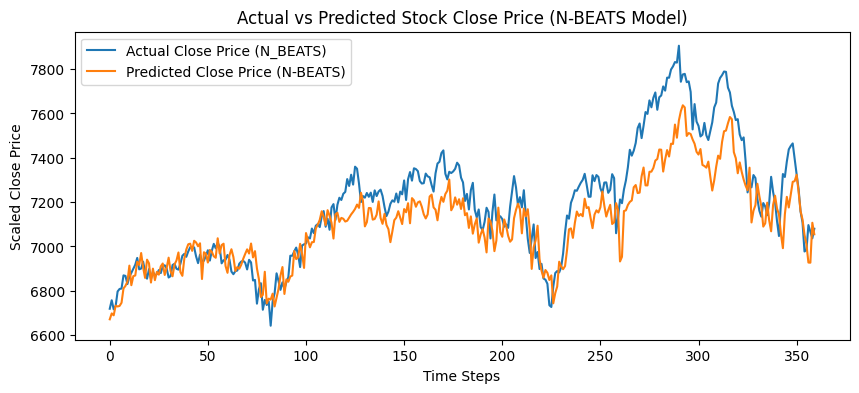

In [24]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(y_true_nbeats3.flatten(), label="Actual Close Price (N_BEATS)")
plt.plot(y_pred_nbeats3.flatten(), label="Predicted Close Price (N-BEATS)")
plt.title("Actual vs Predicted Stock Close Price (N-BEATS Model)")
plt.xlabel("Time Steps")
plt.ylabel("Scaled Close Price")
plt.legend()
plt.show()

# **ARIMA BASELINE WITHOUT SENTIMEN ANALYSIS**

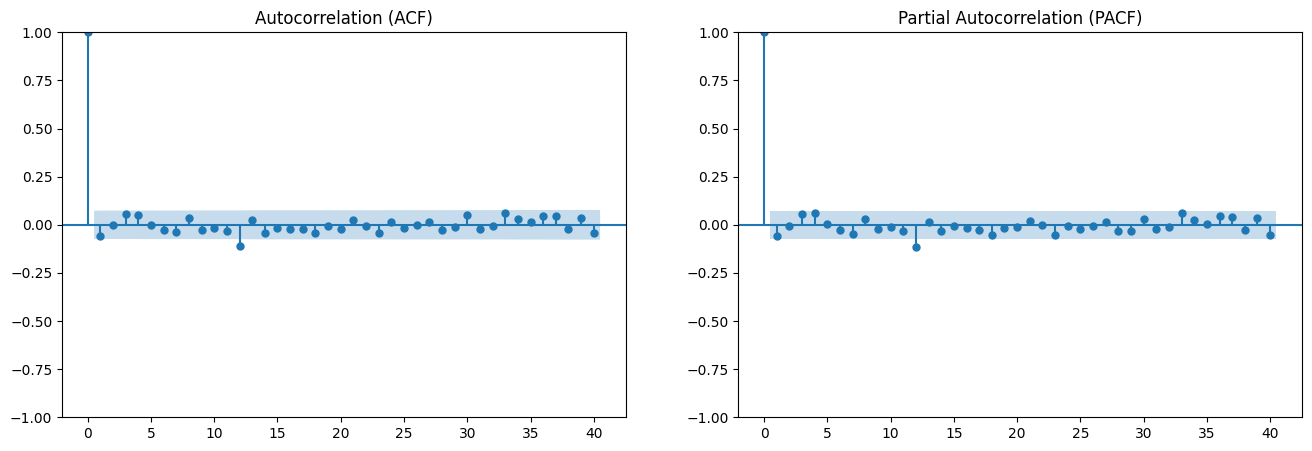

ARIMA(1,0,3) - SAME ORDER AS ARIMAX

Training ARIMA(1, 0, 3)...
                               SARIMAX Results                                
Dep. Variable:          target_scaled   No. Observations:                  236
Model:                 ARIMA(1, 0, 3)   Log Likelihood                 -65.149
Date:                Tue, 03 Mar 2026   AIC                            142.297
Time:                        06:33:58   BIC                            163.080
Sample:                             0   HQIC                           150.675
                                - 236                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1592      0.350     -0.455      0.649      -0.846       0.527
ar.L1          0.9348      0.027     34.695      0.000       0.882 

<Figure size 640x480 with 0 Axes>

Generating diagnostic plots...


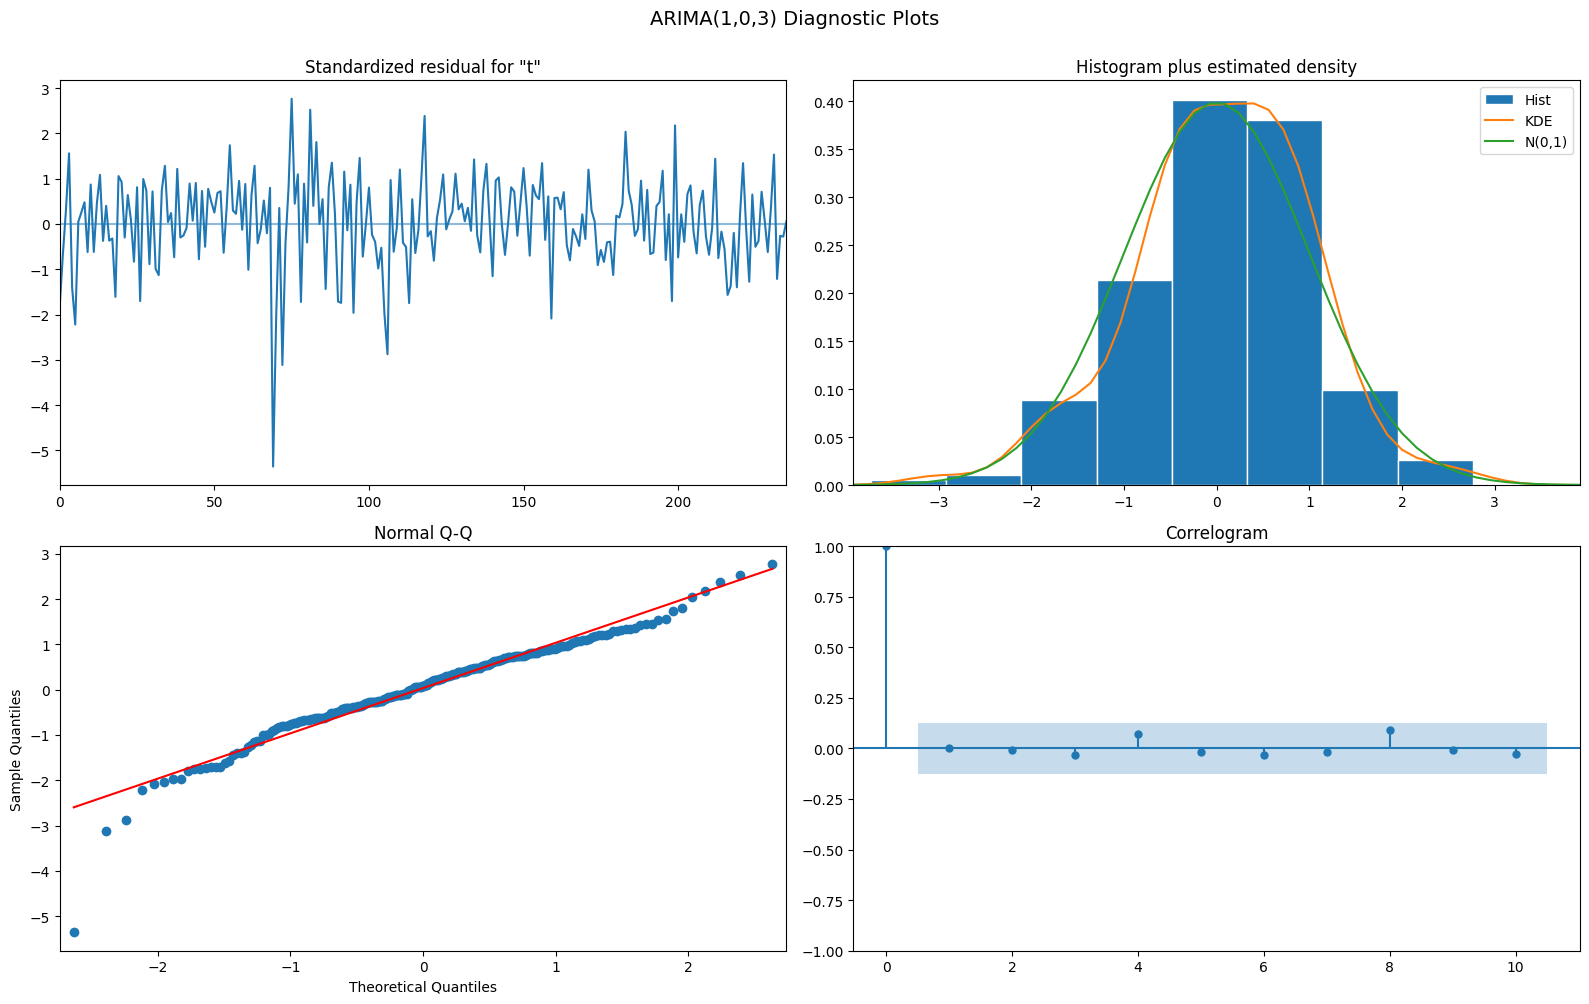


RESULTS SUMMARY
Model: ARIMA(1,0,3)
MSE: 3078.72
MAE: 42.92
RMSE: 55.49
MAPE: 0.60


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

data_diff = df['Terakhir'].diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot ACF
plot_acf(data_diff, lags=40, ax=axes[0])
axes[0].set_title('Autocorrelation (ACF)')

# Plot PACF
plot_pacf(data_diff, lags=40, ax=axes[1], method='ywm')
axes[1].set_title('Partial Autocorrelation (PACF)')

plt.show()

features = feature_cols

y_train_sarimax = train_scaled['target_scaled']
X_train_sarimax = train_scaled[features]

y_val_sarimax = val_scaled['target_scaled']
X_val_sarimax = val_scaled[features]

y_test_sarimax = test_scaled['target_scaled']
X_test_sarimax = test_scaled[features]

print("="*60)
print("ARIMA(1,0,3) - SAME ORDER AS ARIMAX")
print("="*60)

best_order = (1,0,3)

print(f"\nTraining ARIMA{best_order}...")

model_arima = ARIMA(y_train_sarimax, order=best_order)
results_arima = model_arima.fit()

print(results_arima.summary())

print("\n" + "="*60)
print("Performing one-step ahead forecasting...")
print("="*60)

predictions_test_scaled = []

for i in range(len(y_test_sarimax)):
    if i == 0:
        current_model = results_arima
    else:
        updated_endog = pd.concat([y_train_sarimax, y_test_sarimax.iloc[:i]])

        model_updated = ARIMA(updated_endog, order=best_order)

        try:
            current_model = model_updated.fit(start_params=results_arima.params)
        except:
            current_model = model_updated.fit()

    pred_scaled = current_model.forecast(steps=1)
    predictions_test_scaled.append(pred_scaled.values[0])

    if (i + 1) % 50 == 0:
        print(f"  Progress: {i+1}/{len(y_test_sarimax)}")

print(f"Forecasting: {len(predictions_test_scaled)} predictions")

pred_arima = scaler_y.inverse_transform(np.array(predictions_test_scaled).reshape(-1, 1))
y_true_arima = scaler_y.inverse_transform(y_test_sarimax.values.reshape(-1, 1))

mae_arima = mean_absolute_error(y_true_arima, pred_arima)
rmse_arima = np.sqrt(mean_squared_error(y_true_arima, pred_arima))
mape_arima = np.mean(np.abs((y_true_arima - pred_arima) / y_true_arima)) * 100
mse_arima = mean_squared_error(y_true_arima, pred_arima)

print("\n" + "="*60)
print("ARIMA(1,0,2) PERFORMANCE (Test Set)")
print("="*60)
print(f"MAE  : {mae_arima:.2f}")
print(f"RMSE : {rmse_arima:.2f}")
print(f"MAPE : {mape_arima:.2f}%")
print(f"MSE  : {mse_arima:.2f}")

residuals = y_true_arima.flatten() - pred_arima.flatten()
axes[1].plot(residuals, label='Residuals', color='red', alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1].fill_between(range(len(residuals)), residuals, 0, alpha=0.3, color='red')
axes[1].set_xlabel('Time Steps')
axes[1].set_ylabel('Residual')
axes[1].set_title(f'Prediction Residuals - Mean: {residuals.mean():.2f}, Std: {residuals.std():.2f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Generating diagnostic plots...")
fig = results_arima.plot_diagnostics(figsize=(16, 10))
plt.suptitle('ARIMA(1,0,3) Diagnostic Plots', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

results_dict = {
    'Model': 'ARIMA(1,0,3)',
    'MSE': mse_arima,
    'MAE': mae_arima,
    'RMSE': rmse_arima,
    'MAPE': mape_arima
}

print("\n" + "="*60)
print("RESULTS SUMMARY")
print("="*60)
for key, value in results_dict.items():
    if isinstance(value, float):
        print(f"{key}: {value:.2f}")
    else:
        print(f"{key}: {value}")

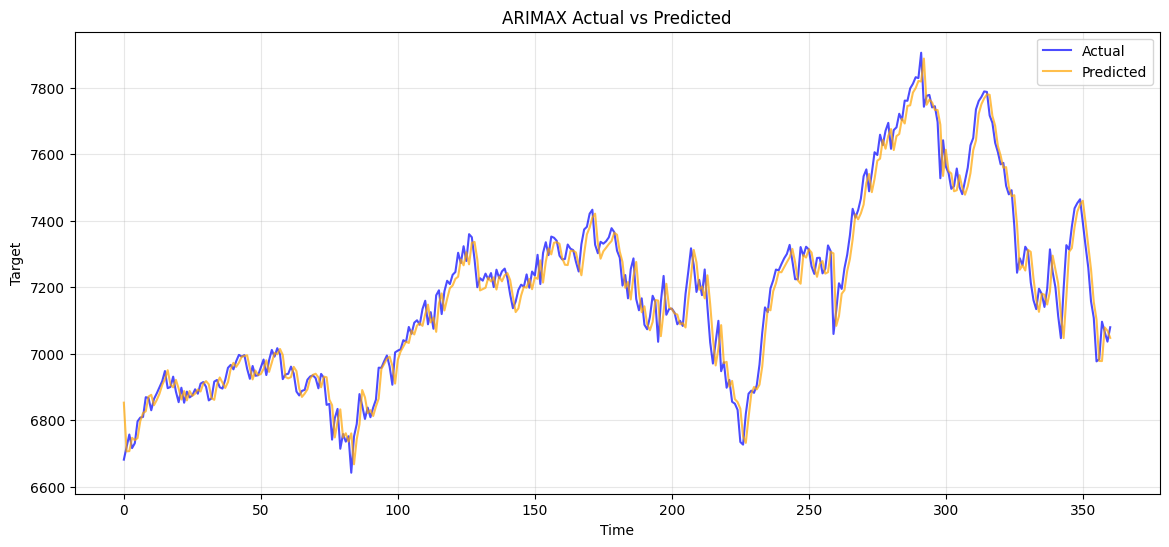

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(y_true_arima, label='Actual', color='blue', alpha=0.7)
plt.plot(pred_arima, label='Predicted', color='orange', alpha=0.7)
plt.title('ARIMAX Actual vs Predicted')
plt.xlabel('Time')
plt.ylabel('Target')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#ACF/PACF Methods

In [27]:
features = feature_cols

y_train_arimax = train_scaled['target_scaled']
X_train_arimax = train_scaled[features]

y_val_arimax = val_scaled['target_scaled']
X_val_arimax = val_scaled[features]

y_test_arimax = test_scaled['target_scaled']
X_test_arimax = test_scaled[features]

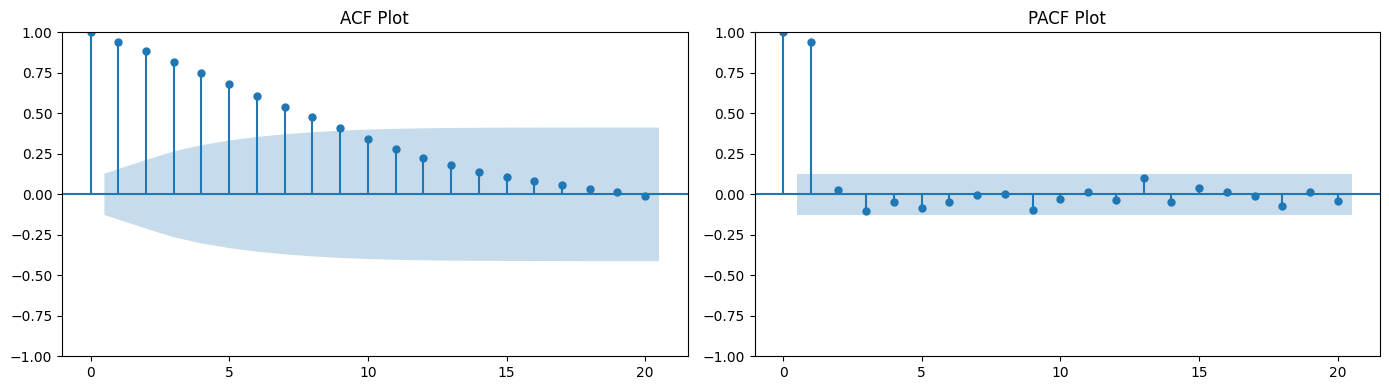

In [28]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

series = train_scaled['target_scaled']

plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
plot_acf(series, lags=20, ax=plt.gca())
plt.title("ACF Plot")

plt.subplot(1, 2, 2)
plot_pacf(series, lags=20, method='ywm', ax=plt.gca())
plt.title("PACF Plot")

plt.tight_layout()
plt.show()


## CANDIDATES FULL

In [29]:
import numpy as np
from statsmodels.tsa.stattools import acf, pacf

nlags = 20
acf_vals, acf_conf = acf(series, nlags=nlags, alpha=0.05)
pacf_vals, pacf_conf = pacf(series, nlags=nlags, alpha=0.05, method='ywm')

# Cari lag signifikan (di luar confidence interval)
q_candidates = np.where(
    (acf_conf[:, 0] > 0) | (acf_conf[:, 1] < 0))[0]

p_candidates = np.where(
    (pacf_conf[:, 0] > 0) | (pacf_conf[:, 1] < 0))[0]

# buang lag 0
q_candidates = q_candidates[q_candidates != 0]
p_candidates = p_candidates[p_candidates != 0]

print("Candidate q (from ACF) FULL:", q_candidates)
print("Candidate p (from PACF) FULL:", p_candidates)

Candidate q (from ACF) FULL: [1 2 3 4 5 6 7 8 9]
Candidate p (from PACF) FULL: [1]


In [30]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

# Kandidat hasil ACF–PACF
p_candidates = [1]
d = 0
q_candidates = [1, 2, 3, 4, 5]

results = []

for p in p_candidates:
    for q in q_candidates:
        order = (p, d, q)
        try:
            model = ARIMA(
                endog=y_train_arimax,
                exog=X_train_arimax,
                order=order
            )
            fitted = model.fit()

            results.append({
                'p': p,
                'd': d,
                'q': q,
                'AIC': fitted.aic,
                'BIC': fitted.bic,
                'HQIC': fitted.hqic
            })

            print(f"ARIMAX{order} | AIC: {fitted.aic:.2f}")

        except Exception as e:
            print(f"ARIMAX{order} failed")

results_df = pd.DataFrame(results)

results_sorted = (
    results_df
    .sort_values(by='AIC')
    .reset_index(drop=True)
)

print("\nRANKING ARIMAX MODELS (BASED ON AIC)")
print("="*60)
print(results_sorted)

ARIMAX(1, 0, 1) | AIC: 185.56
ARIMAX(1, 0, 2) | AIC: 173.92
ARIMAX(1, 0, 3) | AIC: 140.50
ARIMAX(1, 0, 4) | AIC: 144.58
ARIMAX(1, 0, 5) | AIC: 144.24

RANKING ARIMAX MODELS (BASED ON AIC)
   p  d  q         AIC         BIC        HQIC
0  1  0  3  140.502696  195.924005  162.843507
1  1  0  5  144.243846  206.592818  169.377258
2  1  0  4  144.575653  203.460793  168.312764
3  1  0  2  173.921505  225.878982  194.866015
4  1  0  1  185.558439  234.052084  205.106649


# **ARIMAX**


In [31]:
import numpy as np
from statsmodels.tsa.stattools import acf, pacf

nlags = 20
acf_vals, acf_conf = acf(series, nlags=nlags, alpha=0.05)
pacf_vals, pacf_conf = pacf(series, nlags=nlags, alpha=0.05, method='ywm')

# Cari lag signifikan (di luar confidence interval)
q_candidates = np.where(
    (acf_conf[:, 0] > 0) | (acf_conf[:, 1] < 0))[0]

p_candidates = np.where(
    (pacf_conf[:, 0] > 0) | (pacf_conf[:, 1] < 0))[0]

# buang lag 0
q_candidates = q_candidates[q_candidates != 0]
p_candidates = p_candidates[p_candidates != 0]

print("Candidate p (from PACF):", p_candidates[:5])
print("Candidate q (from ACF):", q_candidates[:5])

Candidate p (from PACF): [1]
Candidate q (from ACF): [1 2 3 4 5]


In [32]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

# Kandidat hasil ACF–PACF
p_candidates = [1]
d = 0
q_candidates = [1, 2, 3, 4, 5]

results = []

for p in p_candidates:
    for q in q_candidates:
        order = (p, d, q)
        try:
            model = ARIMA(
                endog=y_train_arimax,
                exog=X_train_arimax,
                order=order
            )
            fitted = model.fit()

            results.append({
                'p': p,
                'd': d,
                'q': q,
                'AIC': fitted.aic,
                'BIC': fitted.bic,
                'HQIC': fitted.hqic
            })

            print(f"ARIMAX{order} | AIC: {fitted.aic:.2f}")

        except Exception as e:
            print(f"ARIMAX{order} failed")

results_df = pd.DataFrame(results)

results_sorted = (
    results_df
    .sort_values(by='AIC')
    .reset_index(drop=True)
)

print("\nRANKING ARIMAX MODELS (BASED ON AIC)")
print("="*60)
print(results_sorted)

ARIMAX(1, 0, 1) | AIC: 185.56
ARIMAX(1, 0, 2) | AIC: 173.92
ARIMAX(1, 0, 3) | AIC: 140.50
ARIMAX(1, 0, 4) | AIC: 144.58
ARIMAX(1, 0, 5) | AIC: 144.24

RANKING ARIMAX MODELS (BASED ON AIC)
   p  d  q         AIC         BIC        HQIC
0  1  0  3  140.502696  195.924005  162.843507
1  1  0  5  144.243846  206.592818  169.377258
2  1  0  4  144.575653  203.460793  168.312764
3  1  0  2  173.921505  225.878982  194.866015
4  1  0  1  185.558439  234.052084  205.106649


In [33]:
from statsmodels.tsa.arima.model import ARIMA

order = (1, 0, 3)

model_arimax = ARIMA(
    endog=y_train_arimax,
    exog=X_train_arimax,
    order=order
)

results_arimax = model_arimax.fit()
print(results_arimax.summary())

                               SARIMAX Results                                
Dep. Variable:          target_scaled   No. Observations:                  236
Model:                 ARIMA(1, 0, 3)   Log Likelihood                 -54.251
Date:                Tue, 03 Mar 2026   AIC                            140.503
Time:                        06:38:24   BIC                            195.924
Sample:                             0   HQIC                           162.844
                                - 236                                         
Covariance Type:                  opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.0170      0.074     -0.228      0.819      -0.163       0.129
Pembukaan         0.1112      0.159      0.701      0.483      -0.200       0.422
Tertinggi        -0.3091      0.103     

In [34]:
import numpy as np

predictions_scaled = []

for i in range(len(y_test_arimax)):
    if i == 0:
        current_model = results_arimax
        pred = current_model.forecast(
            steps=1,
            exog=X_test_arimax.iloc[[i]]
        )
    else:
        updated_y = pd.concat([y_train_arimax, y_test_arimax.iloc[:i]])
        updated_X = pd.concat([X_train_arimax, X_test_arimax.iloc[:i]])

        model_updated = ARIMA(
            endog=updated_y,
            exog=updated_X,
            order=order
        )
        current_model = model_updated.fit()
        pred = current_model.forecast(
            steps=1,
            exog=X_test_arimax.iloc[[i]]
        )

    predictions_scaled.append(pred.values[0])

pred_scaled = np.array(predictions_scaled).reshape(-1, 1)

pred_arimax = scaler_y.inverse_transform(pred_scaled)
y_true_arimax = scaler_y.inverse_transform(
    y_test_arimax.values.reshape(-1, 1))

from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_arimax  = mean_absolute_error(y_true_arimax, pred_arimax)
mse_arimax  = mean_squared_error(y_true_arimax, pred_arimax)
rmse_arimax = np.sqrt(mse_arimax)
mape_arimax = np.mean(
    np.abs((y_true_arimax - pred_arimax) / y_true_arimax)
) * 100

print("ARIMAX Performance:")
print(f"MAE  : {mae_arimax:.2f}")
print(f"MSE  : {mse_arimax:.2f}")
print(f"RMSE : {rmse_arimax:.2f}")
print(f"MAPE : {mape_arimax:.2f}%")

ARIMAX Performance:
MAE  : 43.88
MSE  : 3167.02
RMSE : 56.28
MAPE : 0.61%


In [35]:
from statsmodels.stats.diagnostic import acorr_ljungbox

residuals = results_arimax.resid

ljung_box = acorr_ljungbox(
    residuals,
    lags=[10, 20],
    return_df=True)

print(ljung_box)

      lb_stat  lb_pvalue
10   4.136383   0.940985
20  15.853741   0.725655


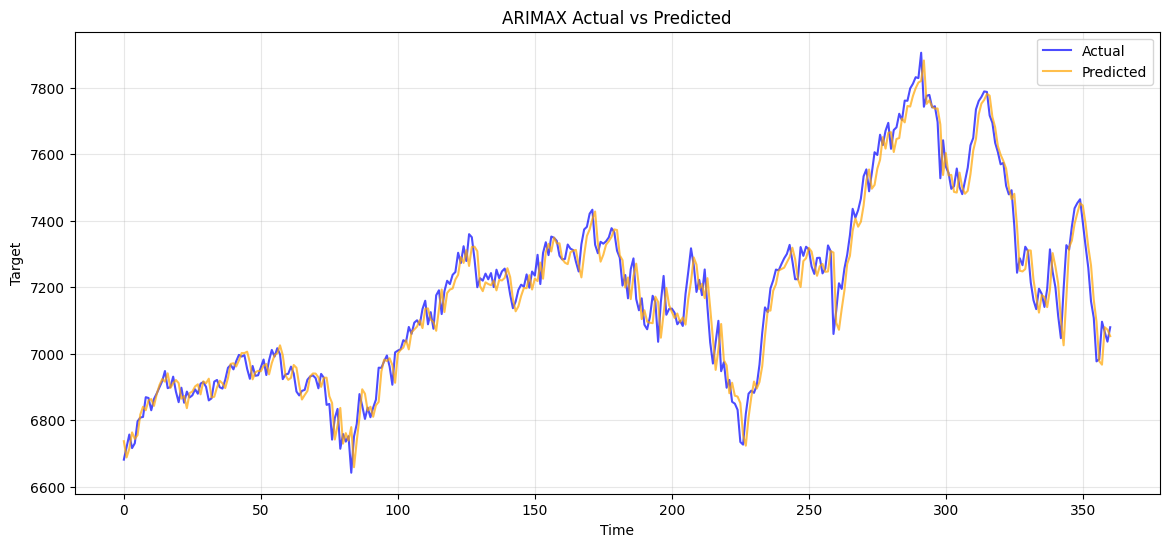

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(y_true_arimax, label='Actual', color='blue', alpha=0.7)
plt.plot(pred_arimax, label='Predicted', color='orange', alpha=0.7)
plt.title('ARIMAX Actual vs Predicted')
plt.xlabel('Time')
plt.ylabel('Target')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# **Comparison Model**

In [37]:
lstm_mae_val = best['test_mae']
lstm_mse_val = best['test_mse']
lstm_rmse_val = best['test_rmse']
lstm_mape_val = best['test_mape']

nbeats_mae_val = mae_nbeats3
nbeats_mse_val = mse_nbeats3
nbeats_rmse_val = rmse_nbeats3
nbeats_mape_val = mape_nbeats3

arima_mae_val = mae_arima
arima_mse_val = mse_arima
arima_rmse_val = rmse_arima
arima_mape_val = mape_arima

arimax_mae_val = mae_arimax
arimax_mse_val = mse_arimax
arimax_rmse_val = rmse_arimax
arimax_mape_val = mape_arimax

metrics_data = {
    'Model': ['LSTM', 'N-BEATS', 'ARIMA', 'ARIMAX'],
    'MSE': [lstm_mse_val, nbeats_mse_val, arima_mse_val, arimax_mse_val],
    'RMSE': [lstm_rmse_val, nbeats_rmse_val, arima_rmse_val, arimax_rmse_val],
    'MAE': [lstm_mae_val, nbeats_mae_val, arima_mae_val, arimax_mae_val],
    'MAPE': [lstm_mape_val, nbeats_mape_val, arima_mape_val, arimax_mape_val],
}

df_metrics = pd.DataFrame(metrics_data)

df_metrics_sorted = df_metrics.sort_values(by='MAPE').reset_index(drop=True)
df_metrics_sorted['Rank'] = df_metrics_sorted.index + 1

print('Model Performance Metrics (Sorted by MAPE):')
print(df_metrics_sorted)

output_filename = 'model_comparison_metrics.csv'
df_metrics_sorted.to_csv(output_filename, index=False)

print(f'Model metrics saved to {output_filename}')

Model Performance Metrics (Sorted by MAPE):
     Model           MSE        RMSE         MAE      MAPE  Rank
0    ARIMA   3078.719111   55.486206   42.922471  0.597397     1
1   ARIMAX   3167.021825   56.276299   43.880617  0.610768     2
2  N-BEATS  19340.230072  139.069156  108.936692  1.486069     3
3     LSTM  26699.162937  163.398785  117.667508  1.592961     4
Model metrics saved to model_comparison_metrics.csv


In [45]:
import joblib

joblib.dump(results_arimax, 'avg_best_arimax_model.joblib')
print("Best ARIMAX model saved as 'avg_best_arimax_model.joblib'")

Best ARIMAX model saved as 'avg_best_arimax_model.joblib'


# **Uji Granger Causality**

In [39]:
from statsmodels.tsa.api import VAR

data_gc = df[['return', 'avg_sentiment']].dropna()
model = VAR(data_gc)
lag_order_results = model.select_order(maxlags=15)

print(lag_order_results.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -11.13     -11.12*   1.464e-05     -11.13*
1      -11.14*      -11.10  1.452e-05*      -11.12
2       -11.13      -11.07   1.463e-05      -11.11
3       -11.13      -11.04   1.470e-05      -11.09
4       -11.13      -11.01   1.472e-05      -11.08
5       -11.12      -10.98   1.480e-05      -11.07
6       -11.11      -10.94   1.495e-05      -11.05
7       -11.10      -10.91   1.505e-05      -11.03
8       -11.10      -10.88   1.505e-05      -11.02
9       -11.10      -10.85   1.518e-05      -11.00
10      -11.09      -10.82   1.526e-05      -10.98
11      -11.08      -10.78   1.542e-05      -10.96
12      -11.09      -10.76   1.529e-05      -10.96
13      -11.09      -10.74   1.530e-05      -10.95
14      -11.08      -10.70   1.544e-05      -10.93
15      -11.07      -10.67   1.553e-05      -10.92
-------------------------------

In [40]:
from statsmodels.tsa.stattools import grangercausalitytests

granger_result = grangercausalitytests(
    df[['return', 'avg_sentiment']],
    maxlag=1
)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.5783  , p=0.4472  , df_denom=708, df_num=1
ssr based chi2 test:   chi2=0.5808  , p=0.4460  , df=1
likelihood ratio test: chi2=0.5805  , p=0.4461  , df=1
parameter F test:         F=0.5783  , p=0.4472  , df_denom=708, df_num=1


In [41]:
from statsmodels.tsa.api import VAR

data_gc = df[['Terakhir', 'avg_sentiment']].dropna()
model = VAR(data_gc)
lag_order_results = model.select_order(maxlags=15)

print(lag_order_results.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        9.790       9.803   1.786e+04       9.795
1        6.587      6.626*       725.3      6.602*
2       6.584*       6.649      723.1*       6.609
3        6.591       6.682       728.6       6.626
4        6.593       6.710       729.8       6.638
5        6.593       6.736       729.8       6.648
6        6.602       6.771       736.3       6.667
7        6.611       6.806       743.1       6.686
8        6.612       6.834       744.2       6.698
9        6.616       6.864       747.0       6.712
10       6.626       6.900       754.7       6.732
11       6.634       6.934       760.3       6.750
12       6.640       6.966       764.8       6.766
13       6.631       6.983       758.3       6.767
14       6.637       7.015       762.9       6.783
15       6.645       7.050       769.3       6.802
-------------------------------

In [42]:
from statsmodels.tsa.stattools import grangercausalitytests

granger_result = grangercausalitytests(
    df[['Terakhir', 'avg_sentiment']],
    maxlag=2
)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.4547  , p=0.5003  , df_denom=708, df_num=1
ssr based chi2 test:   chi2=0.4567  , p=0.4992  , df=1
likelihood ratio test: chi2=0.4565  , p=0.4993  , df=1
parameter F test:         F=0.4547  , p=0.5003  , df_denom=708, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.7507  , p=0.4724  , df_denom=705, df_num=2
ssr based chi2 test:   chi2=1.5120  , p=0.4695  , df=2
likelihood ratio test: chi2=1.5104  , p=0.4699  , df=2
parameter F test:         F=0.7507  , p=0.4724  , df_denom=705, df_num=2
